# ExploreWindLayersConfigC

Notebook exploratorio para decidir cómo representar el viento en ConfigC.

Este notebook no modifica el pipeline principal. Su objetivo es visualizar, para una muestra real:

- WindU
- WindV
- WindSpeed
- WindDirectionDegrees
- WindSin
- WindCos
- SolarZenithNorm
- Vector de viento

La decisión final sobre ConfigC se hará después de revisar estas salidas.

In [10]:
from pathlib import Path
import sys
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ProjectRoot = Path("/data/users/kabasmen/MethaneProjectTFM")

if str(ProjectRoot) not in sys.path:
    sys.path.insert(0, str(ProjectRoot))

from Source.VisualizationStyle import (
    LoadVisualizationConfig,
    ApplyMatplotlibStyle,
    GetSaveParameters,
)

RunTag = "Exp242351"
RunRoot = ProjectRoot / "Outputs" / "Experiments" / RunTag

InputTable = RunRoot / "Tables" / "DatasetFiltered.csv"
OutputFigureDir = RunRoot / "ConfigC" / "Figures"
OutputTableDir = RunRoot / "ConfigC" / "Tables"

OutputFigureDir.mkdir(parents=True, exist_ok=True)
OutputTableDir.mkdir(parents=True, exist_ok=True)

VisualConfig = LoadVisualizationConfig(ProjectRoot / "Configs" / "VisualizationConfig.yaml")
ApplyMatplotlibStyle(VisualConfig)

print("ProjectRoot:", ProjectRoot)
print("RunRoot:", RunRoot)
print("InputTable exists:", InputTable.exists())
print("OutputFigureDir:", OutputFigureDir)
print("OutputTableDir:", OutputTableDir)

ProjectRoot: /data/users/kabasmen/MethaneProjectTFM
RunRoot: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351
InputTable exists: True
OutputFigureDir: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Figures
OutputTableDir: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Tables


In [11]:
DatasetFiltered = pd.read_csv(InputTable)

print("Rows:", len(DatasetFiltered))
print("Columns:", len(DatasetFiltered.columns))

RequiredColumns = [
    "SampleId",
    "meteo:wind_u",
    "meteo:wind_v",
    "satellite:sza",
]

MissingColumns = [Column for Column in RequiredColumns if Column not in DatasetFiltered.columns]

if MissingColumns:
    raise KeyError(f"Faltan columnas requeridas para este notebook: {MissingColumns}")

DatasetFiltered[RequiredColumns].head()

Rows: 3519
Columns: 46


,SampleId,meteo:wind_u,meteo:wind_v,satellite:sza
0,681256b9-41d5-4d9d-9063-d5fa17773661,-0.889798,-2.142312,36.481823
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,-1.876772,3.768559,16.324541
2,101031f1-3f77-4029-9172-fee5b35a6e5f,1.678992,0.428121,21.836166
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,-5.022003,5.710159,20.377953
4,2f334079-9187-4116-bf0a-f98d4bbd5236,-3.734330,2.595779,17.036350


## Selección de muestra

Por defecto se usa la primera muestra filtrada. También puedes cambiar `SampleIndex` o fijar manualmente `SampleId`.

In [12]:
SampleIndex = 0

SampleRow = DatasetFiltered.iloc[SampleIndex]
SampleId = str(SampleRow["SampleId"])

WindU = float(SampleRow["meteo:wind_u"])
WindV = float(SampleRow["meteo:wind_v"])
SolarZenith = float(SampleRow["satellite:sza"])

print("SampleId:", SampleId)
print("WindU:", WindU)
print("WindV:", WindV)
print("SolarZenith:", SolarZenith)

SampleId: 681256b9-41d5-4d9d-9063-d5fa17773661
WindU: -0.88979805
WindV: -2.1423118
SolarZenith: 36.481823


## Cálculo de variables de viento

Convenciones:

- `WindSpeed = sqrt(WindU² + WindV²)`
- `WindDirectionRadians = atan2(WindV, WindU)`
- `WindSin = WindV / WindSpeed`
- `WindCos = WindU / WindSpeed`
- `SolarZenithNorm = SolarZenith / 90`

Estas variables se expanden a capas constantes de tamaño `200 × 200`, porque el metadato meteorológico está asociado a la muestra completa.

In [13]:
Height = 200
Width = 200

WindSpeed = math.sqrt(WindU ** 2 + WindV ** 2)

if WindSpeed > 0:
    WindSin = WindV / WindSpeed
    WindCos = WindU / WindSpeed
else:
    WindSin = 0.0
    WindCos = 0.0

WindDirectionRadians = math.atan2(WindV, WindU)
WindDirectionDegrees = (math.degrees(WindDirectionRadians) + 360.0) % 360.0

SolarZenithNorm = SolarZenith / 90.0

ContextValues = {
    "SampleId": SampleId,
    "WindU": WindU,
    "WindV": WindV,
    "WindSpeed": WindSpeed,
    "WindDirectionDegrees": WindDirectionDegrees,
    "WindSin": WindSin,
    "WindCos": WindCos,
    "SolarZenith": SolarZenith,
    "SolarZenithNorm": SolarZenithNorm,
}

ContextValues

{'SampleId': '681256b9-41d5-4d9d-9063-d5fa17773661',
 'WindU': -0.88979805,
 'WindV': -2.1423118,
 'WindSpeed': 2.3197500766683987,
 'WindDirectionDegrees': 247.44469931851478,
 'WindSin': -0.9235097442379508,
 'WindCos': -0.3835749630744355,
 'SolarZenith': 36.481823,
 'SolarZenithNorm': 0.4053535888888889}

In [14]:
def ExpandScalar(Value, Height=200, Width=200):
    return np.full((Height, Width), float(Value), dtype=np.float32)

Layers = {
    "WindU": ExpandScalar(WindU, Height, Width),
    "WindV": ExpandScalar(WindV, Height, Width),
    "WindSpeed": ExpandScalar(WindSpeed, Height, Width),
    "WindDirectionDegrees": ExpandScalar(WindDirectionDegrees, Height, Width),
    "WindSin": ExpandScalar(WindSin, Height, Width),
    "WindCos": ExpandScalar(WindCos, Height, Width),
    "SolarZenithNorm": ExpandScalar(SolarZenithNorm, Height, Width),
}

for Name, Array in Layers.items():
    print(Name, Array.shape, float(Array.min()), float(Array.max()))

WindU (200, 200) -0.8897980451583862 -0.8897980451583862
WindV (200, 200) -2.1423118114471436 -2.1423118114471436
WindSpeed (200, 200) 2.3197500705718994 2.3197500705718994
WindDirectionDegrees (200, 200) 247.4447021484375 247.4447021484375
WindSin (200, 200) -0.9235097169876099 -0.9235097169876099
WindCos (200, 200) -0.3835749626159668 -0.3835749626159668
SolarZenithNorm (200, 200) 0.4053535759449005 0.4053535759449005


## Guardar tabla exploratoria

Esta tabla registra los valores escalares usados para generar las capas.

In [15]:
OutputTable = OutputTableDir / f"WindLayerPrototype_{SampleId}.csv"
pd.DataFrame([ContextValues]).to_csv(OutputTable, index=False)
OutputTable

PosixPath('/data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Tables/WindLayerPrototype_681256b9-41d5-4d9d-9063-d5fa17773661.csv')

## Visualización de capas constantes

Nota: estas capas se ven uniformes porque cada variable es un metadato global de la muestra. Para la red neuronal, funcionan como canales contextuales constantes.

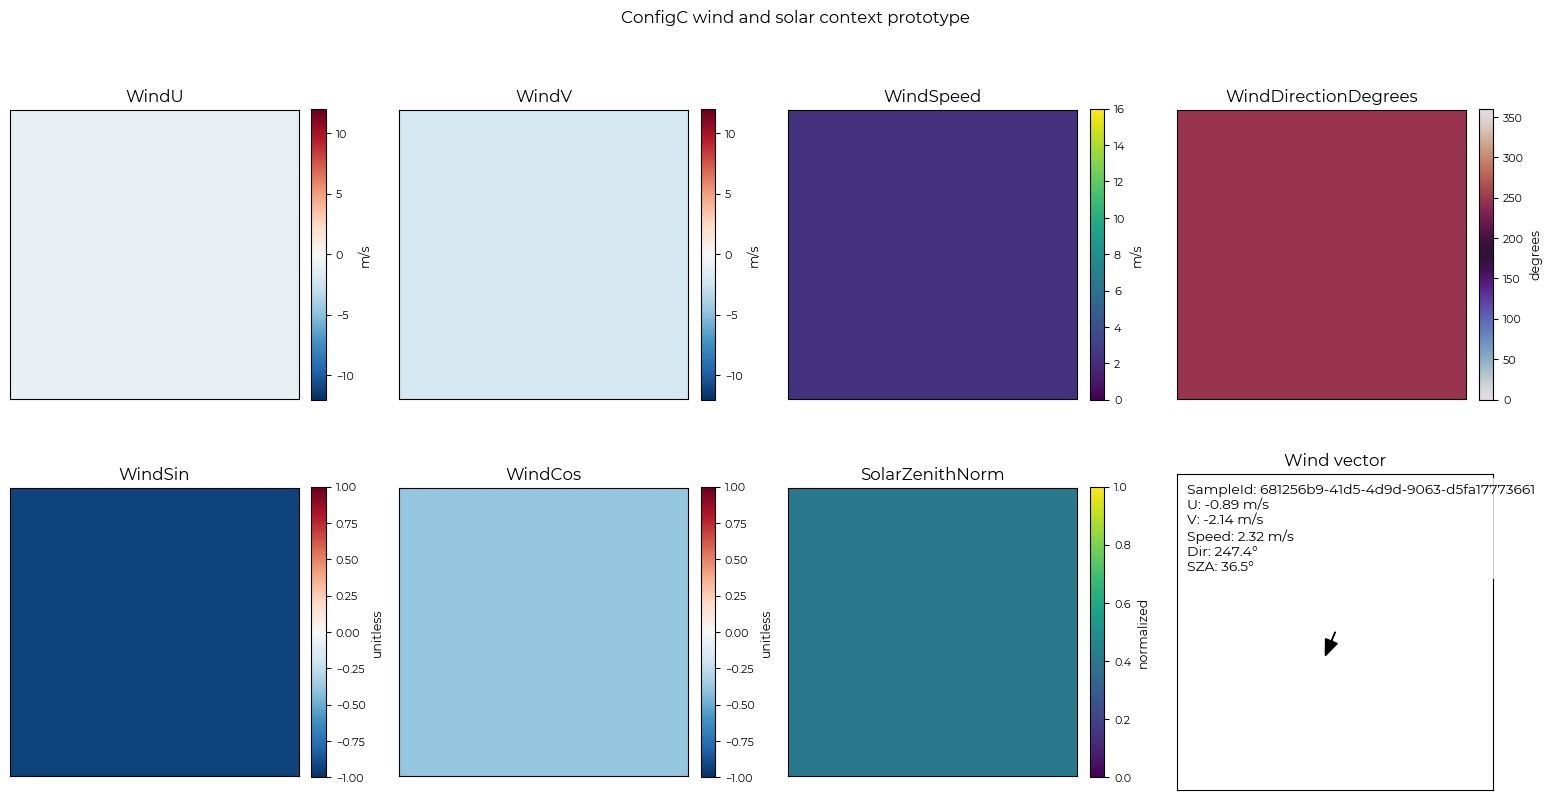

PosixPath('/data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Figures/WindLayerPrototype_681256b9-41d5-4d9d-9063-d5fa17773661.png')

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

PlotItems = [
    ("WindU", "RdBu_r", -12, 12, "m/s"),
    ("WindV", "RdBu_r", -12, 12, "m/s"),
    ("WindSpeed", "viridis", 0, 16, "m/s"),
    ("WindDirectionDegrees", "twilight", 0, 360, "degrees"),
    ("WindSin", "RdBu_r", -1, 1, "unitless"),
    ("WindCos", "RdBu_r", -1, 1, "unitless"),
    ("SolarZenithNorm", "viridis", 0, 1, "normalized"),
]

for Axis, Item in zip(axes.flat, PlotItems):
    Name, Cmap, Vmin, Vmax, Label = Item
    Image = Axis.imshow(Layers[Name], cmap=Cmap, vmin=Vmin, vmax=Vmax)
    Axis.set_title(Name)
    Axis.set_xticks([])
    Axis.set_yticks([])
    Cbar = fig.colorbar(Image, ax=Axis, fraction=0.046, pad=0.04)
    Cbar.set_label(Label)

# Último panel: vector de viento
Axis = axes.flat[-1]
Axis.set_title("Wind vector")
Axis.set_xlim(0, Width)
Axis.set_ylim(Height, 0)
Axis.set_aspect("equal")
Axis.set_xticks([])
Axis.set_yticks([])

CenterX = Width / 2
CenterY = Height / 2

Scale = 7.0
Axis.arrow(
    CenterX,
    CenterY,
    WindU * Scale,
    -WindV * Scale,
    head_width=8,
    head_length=10,
    length_includes_head=True,
    color="black",
)

Axis.text(
    0.03,
    0.97,
    f"SampleId: {SampleId}\n"
    f"U: {WindU:.2f} m/s\n"
    f"V: {WindV:.2f} m/s\n"
    f"Speed: {WindSpeed:.2f} m/s\n"
    f"Dir: {WindDirectionDegrees:.1f}°\n"
    f"SZA: {SolarZenith:.1f}°",
    transform=Axis.transAxes,
    va="top",
    ha="left",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
)

fig.suptitle("ConfigC wind and solar context prototype", y=1.02)
fig.tight_layout()

OutputFigure = OutputFigureDir / f"WindLayerPrototype_{SampleId}.png"
fig.savefig(OutputFigure, **GetSaveParameters(VisualConfig))
plt.show()

OutputFigure

## Interpretación técnica

Observaciones a revisar:

1. `WindU` y `WindV` preservan el signo y magnitud de las componentes originales.
2. `WindSin` y `WindCos` representan dirección de forma estable y evitan discontinuidades angulares.
3. `WindSpeed` aporta magnitud.
4. `SolarZenithNorm` representa geometría de iluminación, pero no dirección solar.
5. Como no existe `SolarAzimuth`, no se deben incluir `SolarAzimuthSin` ni `SolarAzimuthCos`.

Decisión pendiente:

- ConfigC cartesian: `ConfigB + WindU + WindV + SolarZenithNorm`
- ConfigC polar: `ConfigB + WindSin + WindCos + WindSpeed + SolarZenithNorm`
- ConfigC both: `ConfigB + WindU + WindV + WindSin + WindCos + WindSpeed + SolarZenithNorm`

## Exploración global de variables contextuales

Ahora analizamos todas las muestras filtradas del experimento para decidir si el viento debe entrar en ConfigC como:

1. Componentes cartesianas: `WindU`, `WindV`
2. Representación polar: `WindSin`, `WindCos`, `WindSpeed`
3. Ambas representaciones
4. Variable solar disponible: `SolarZenithNorm`

Esta exploración no modifica el pipeline. Solo genera evidencia tabular y visual.

In [17]:
ContextRows = []

for _, Row in DatasetFiltered.iterrows():
    SampleIdGlobal = str(Row["SampleId"])
    WindUGlobal = float(Row["meteo:wind_u"])
    WindVGlobal = float(Row["meteo:wind_v"])
    SolarZenithGlobal = float(Row["satellite:sza"])

    WindSpeedGlobal = math.sqrt(WindUGlobal ** 2 + WindVGlobal ** 2)

    if WindSpeedGlobal > 0:
        WindSinGlobal = WindVGlobal / WindSpeedGlobal
        WindCosGlobal = WindUGlobal / WindSpeedGlobal
    else:
        WindSinGlobal = 0.0
        WindCosGlobal = 0.0

    WindDirectionRadiansGlobal = math.atan2(WindVGlobal, WindUGlobal)
    WindDirectionDegreesGlobal = (math.degrees(WindDirectionRadiansGlobal) + 360.0) % 360.0

    SolarZenithNormGlobal = SolarZenithGlobal / 90.0

    ContextRows.append(
        {
            "SampleId": SampleIdGlobal,
            "WindU": WindUGlobal,
            "WindV": WindVGlobal,
            "WindSpeed": WindSpeedGlobal,
            "WindDirectionDegrees": WindDirectionDegreesGlobal,
            "WindSin": WindSinGlobal,
            "WindCos": WindCosGlobal,
            "SolarZenith": SolarZenithGlobal,
            "SolarZenithNorm": SolarZenithNormGlobal,
        }
    )

WindContextBySample = pd.DataFrame(ContextRows)

NumericColumns = [
    "WindU",
    "WindV",
    "WindSpeed",
    "WindDirectionDegrees",
    "WindSin",
    "WindCos",
    "SolarZenith",
    "SolarZenithNorm",
]

if not np.isfinite(WindContextBySample[NumericColumns].to_numpy(dtype=float)).all():
    raise ValueError("WindContextBySample contiene NaN o Inf.")

OutputContextTable = OutputTableDir / "WindContextBySample.csv"
WindContextBySample.to_csv(OutputContextTable, index=False)

print("Saved:", OutputContextTable)
print("Rows:", len(WindContextBySample))
WindContextBySample.head()

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Tables/WindContextBySample.csv
Rows: 3519


,SampleId,WindU,WindV,WindSpeed,WindDirectionDegrees,WindSin,WindCos,SolarZenith,SolarZenithNorm
0,681256b9-41d5-4d9d-9063-d5fa17773661,-0.889798,-2.142312,2.319750,247.444699,-0.923510,-0.383575,36.481823,0.405354
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,-1.876772,3.768559,4.210025,116.473658,0.895139,-0.445786,16.324541,0.181384
2,101031f1-3f77-4029-9172-fee5b35a6e5f,1.678992,0.428121,1.732715,14.304853,0.247081,0.968995,21.836166,0.242624
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,-5.022003,5.710159,7.604369,131.331164,0.750905,-0.660410,20.377953,0.226422
4,2f334079-9187-4116-bf0a-f98d4bbd5236,-3.734330,2.595779,4.547889,145.196355,0.570766,-0.821113,17.036350,0.189293


In [18]:
SummaryRows = []

for Column in NumericColumns:
    Values = WindContextBySample[Column].to_numpy(dtype=float)

    SummaryRows.append(
        {
            "Variable": Column,
            "Count": int(len(Values)),
            "Mean": float(np.mean(Values)),
            "Std": float(np.std(Values)),
            "Min": float(np.min(Values)),
            "P01": float(np.percentile(Values, 1)),
            "P05": float(np.percentile(Values, 5)),
            "P25": float(np.percentile(Values, 25)),
            "Median": float(np.percentile(Values, 50)),
            "P75": float(np.percentile(Values, 75)),
            "P95": float(np.percentile(Values, 95)),
            "P99": float(np.percentile(Values, 99)),
            "Max": float(np.max(Values)),
        }
    )

WindSpeedValues = WindContextBySample["WindSpeed"].to_numpy(dtype=float)

SummaryRows.append(
    {
        "Variable": "WindSpeedBelow0_5ms",
        "Count": int((WindSpeedValues < 0.5).sum()),
        "Mean": float((WindSpeedValues < 0.5).mean()),
        "Std": np.nan,
        "Min": np.nan,
        "P01": np.nan,
        "P05": np.nan,
        "P25": np.nan,
        "Median": np.nan,
        "P75": np.nan,
        "P95": np.nan,
        "P99": np.nan,
        "Max": np.nan,
    }
)

SummaryRows.append(
    {
        "Variable": "WindSpeedBelow1_0ms",
        "Count": int((WindSpeedValues < 1.0).sum()),
        "Mean": float((WindSpeedValues < 1.0).mean()),
        "Std": np.nan,
        "Min": np.nan,
        "P01": np.nan,
        "P05": np.nan,
        "P25": np.nan,
        "Median": np.nan,
        "P75": np.nan,
        "P95": np.nan,
        "P99": np.nan,
        "Max": np.nan,
    }
)

WindContextSummary = pd.DataFrame(SummaryRows)

OutputSummaryTable = OutputTableDir / "WindContextSummary.csv"
WindContextSummary.to_csv(OutputSummaryTable, index=False)

print("Saved:", OutputSummaryTable)
WindContextSummary

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Tables/WindContextSummary.csv


,Variable,Count,Mean,Std,Min,P01,P05,P25,Median,P75,P95,P99,Max
0,WindU,3519,-0.790657,3.109673,-11.296280,-7.655479,-5.800775,-3.028322,-0.798802,1.427979,4.339076,6.270759,9.166214
1,WindV,3519,0.136295,2.800202,-9.783691,-6.912016,-4.498568,-1.654669,0.146042,2.088004,4.572535,6.491717,9.935712
2,WindSpeed,3519,3.787961,1.950964,0.089677,0.440961,0.987456,2.316574,3.579583,5.034123,7.372794,8.822747,12.166351
3,WindDirectionDegrees,3519,180.865806,94.296365,0.164255,5.043582,23.946747,115.522070,175.031578,253.739806,340.780234,355.392832,359.930701
4,WindSin,3519,0.026575,0.675558,-1.000000,-0.999043,-0.980155,-0.611005,0.060136,0.675334,0.981182,0.999253,1.000000
5,WindCos,3519,-0.164943,0.718129,-0.999999,-0.999785,-0.993891,-0.862941,-0.366102,0.535515,0.980835,0.999020,0.999999
6,SolarZenith,3519,35.650639,13.600950,15.835876,16.593511,18.700092,23.123151,32.995403,47.637525,58.089724,63.250790,68.336130
7,SolarZenithNorm,3519,0.396118,0.151122,0.175954,0.184372,0.207779,0.256924,0.366616,0.529306,0.645441,0.702787,0.759290
8,WindSpeedBelow0_5ms,48,0.013640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,WindSpeedBelow1_0ms,182,0.051719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


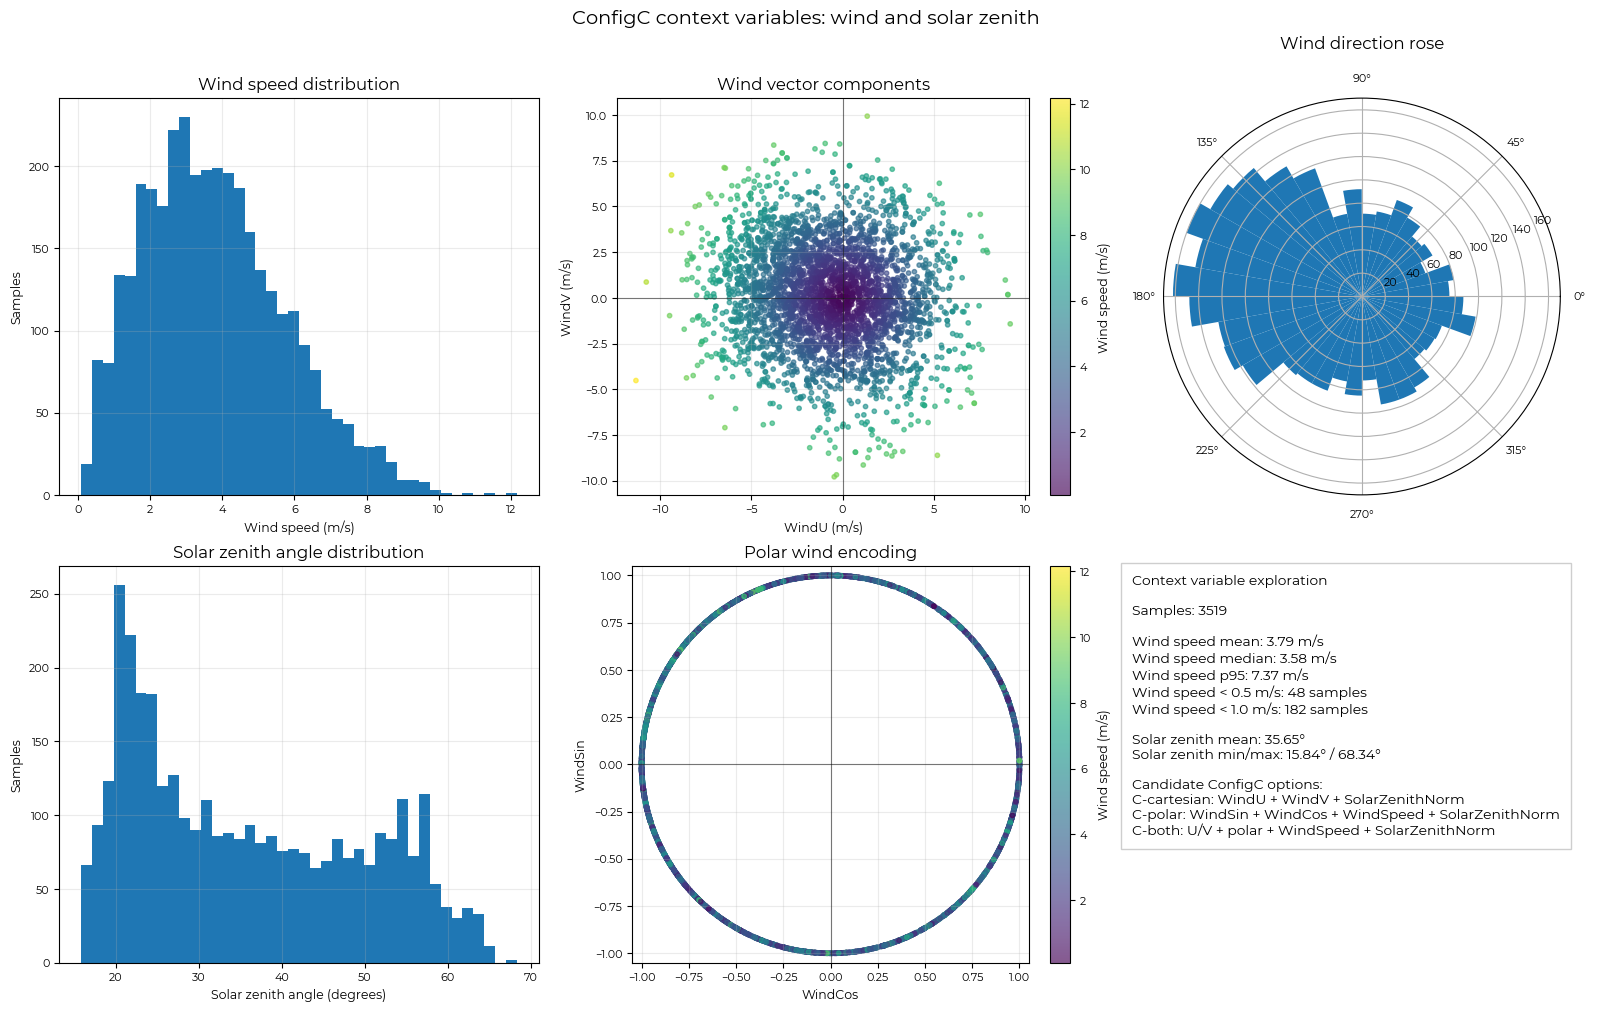

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp242351/ConfigC/Figures/WindContextOverview.png


In [19]:
Figure = plt.figure(figsize=(16, 10), constrained_layout=True)
Grid = Figure.add_gridspec(2, 3)

AxisSpeed = Figure.add_subplot(Grid[0, 0])
AxisUV = Figure.add_subplot(Grid[0, 1])
AxisDirection = Figure.add_subplot(Grid[0, 2], projection="polar")
AxisZenith = Figure.add_subplot(Grid[1, 0])
AxisSinCos = Figure.add_subplot(Grid[1, 1])
AxisText = Figure.add_subplot(Grid[1, 2])

WindSpeedValues = WindContextBySample["WindSpeed"].to_numpy(dtype=float)
WindUValues = WindContextBySample["WindU"].to_numpy(dtype=float)
WindVValues = WindContextBySample["WindV"].to_numpy(dtype=float)
WindDirectionRadiansValues = np.deg2rad(
    WindContextBySample["WindDirectionDegrees"].to_numpy(dtype=float)
)
SolarZenithValues = WindContextBySample["SolarZenith"].to_numpy(dtype=float)
WindSinValues = WindContextBySample["WindSin"].to_numpy(dtype=float)
WindCosValues = WindContextBySample["WindCos"].to_numpy(dtype=float)

AxisSpeed.hist(WindSpeedValues, bins=40)
AxisSpeed.set_title("Wind speed distribution")
AxisSpeed.set_xlabel("Wind speed (m/s)")
AxisSpeed.set_ylabel("Samples")
AxisSpeed.grid(alpha=0.25)

ScatterUV = AxisUV.scatter(
    WindUValues,
    WindVValues,
    c=WindSpeedValues,
    s=10,
    alpha=0.65,
    cmap="viridis",
)
AxisUV.axhline(0, linewidth=0.8, color="black", alpha=0.5)
AxisUV.axvline(0, linewidth=0.8, color="black", alpha=0.5)
AxisUV.set_title("Wind vector components")
AxisUV.set_xlabel("WindU (m/s)")
AxisUV.set_ylabel("WindV (m/s)")
AxisUV.set_aspect("equal", adjustable="box")
AxisUV.grid(alpha=0.25)

ColorbarUV = Figure.colorbar(ScatterUV, ax=AxisUV, fraction=0.046, pad=0.04)
ColorbarUV.set_label("Wind speed (m/s)")

AxisDirection.hist(WindDirectionRadiansValues, bins=36)
AxisDirection.set_title("Wind direction rose", pad=18)
AxisDirection.set_theta_zero_location("E")
AxisDirection.set_theta_direction(1)

AxisZenith.hist(SolarZenithValues, bins=40)
AxisZenith.set_title("Solar zenith angle distribution")
AxisZenith.set_xlabel("Solar zenith angle (degrees)")
AxisZenith.set_ylabel("Samples")
AxisZenith.grid(alpha=0.25)

ScatterPolar = AxisSinCos.scatter(
    WindCosValues,
    WindSinValues,
    c=WindSpeedValues,
    s=10,
    alpha=0.65,
    cmap="viridis",
)
AxisSinCos.axhline(0, linewidth=0.8, color="black", alpha=0.5)
AxisSinCos.axvline(0, linewidth=0.8, color="black", alpha=0.5)
AxisSinCos.set_title("Polar wind encoding")
AxisSinCos.set_xlabel("WindCos")
AxisSinCos.set_ylabel("WindSin")
AxisSinCos.set_aspect("equal", adjustable="box")
AxisSinCos.set_xlim(-1.05, 1.05)
AxisSinCos.set_ylim(-1.05, 1.05)
AxisSinCos.grid(alpha=0.25)

ColorbarPolar = Figure.colorbar(ScatterPolar, ax=AxisSinCos, fraction=0.046, pad=0.04)
ColorbarPolar.set_label("Wind speed (m/s)")

AxisText.axis("off")

TextLines = [
    "Context variable exploration",
    "",
    f"Samples: {len(WindContextBySample)}",
    "",
    f"Wind speed mean: {WindSpeedValues.mean():.2f} m/s",
    f"Wind speed median: {np.median(WindSpeedValues):.2f} m/s",
    f"Wind speed p95: {np.percentile(WindSpeedValues, 95):.2f} m/s",
    f"Wind speed < 0.5 m/s: {(WindSpeedValues < 0.5).sum()} samples",
    f"Wind speed < 1.0 m/s: {(WindSpeedValues < 1.0).sum()} samples",
    "",
    f"Solar zenith mean: {SolarZenithValues.mean():.2f}°",
    f"Solar zenith min/max: {SolarZenithValues.min():.2f}° / {SolarZenithValues.max():.2f}°",
    "",
    "Candidate ConfigC options:",
    "C-cartesian: WindU + WindV + SolarZenithNorm",
    "C-polar: WindSin + WindCos + WindSpeed + SolarZenithNorm",
    "C-both: U/V + polar + WindSpeed + SolarZenithNorm",
]

AxisText.text(
    0.02,
    0.98,
    "\n".join(TextLines),
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.95, pad=8),
)

Figure.suptitle("ConfigC context variables: wind and solar zenith", fontsize=14)

OutputOverviewFigure = OutputFigureDir / "WindContextOverview.png"
Figure.savefig(OutputOverviewFigure, **GetSaveParameters(VisualConfig))
plt.show()

print("Saved:", OutputOverviewFigure)

Nueva ejecución

In [2]:
# =============================================================================
# Normalizar identificador de muestra y columnas de viento
# =============================================================================

import numpy as np
import pandas as pd

print("Columnas disponibles en SampleTable:")
print(list(SampleTable.columns))

# 1. Detectar columna de ID real
IdCandidates = ["SampleId", "sample_id", "id", "Id", "ID"]

IdCol = None
for c in IdCandidates:
    if c in SampleTable.columns:
        IdCol = c
        break

# Si no hay columna clara, usar índice
SampleTable = SampleTable.copy()

if IdCol is None:
    print("No encontré columna explícita de ID. Usaré el índice como SampleId.")
    SampleTable["SampleId"] = SampleTable.index.astype(str)
    IdCol = "SampleId"
else:
    print("Columna de ID detectada:", IdCol)
    SampleTable["SampleId"] = SampleTable[IdCol].astype(str)

# 2. Detectar columnas de viento
WindUCol = "meteo:wind_u"
WindVCol = "meteo:wind_v"
WindSourceCol = "detection:wind_source"

for col in [WindUCol, WindVCol, WindSourceCol]:
    if col not in SampleTable.columns:
        raise KeyError(
            f"No encontré {col}. Columnas relacionadas con wind: "
            f"{[c for c in SampleTable.columns if 'wind' in c.lower()]}"
        )

# 3. Crear variables físicas del viento
eps = 1e-6

SampleTable["WindU"] = pd.to_numeric(SampleTable[WindUCol], errors="coerce")
SampleTable["WindV"] = pd.to_numeric(SampleTable[WindVCol], errors="coerce")

SampleTable["WindSpeed10m"] = np.sqrt(
    SampleTable["WindU"] ** 2 + SampleTable["WindV"] ** 2
)

SampleTable["WindDirRad_To"] = np.arctan2(
    SampleTable["WindV"],
    SampleTable["WindU"],
)

SampleTable["WindDirDeg_To"] = (
    np.degrees(SampleTable["WindDirRad_To"]) + 360
) % 360

SampleTable["WindDirCos10m"] = SampleTable["WindU"] / (
    SampleTable["WindSpeed10m"] + eps
)

SampleTable["WindDirSin10m"] = SampleTable["WindV"] / (
    SampleTable["WindSpeed10m"] + eps
)

print("\nSampleTable shape:", SampleTable.shape)
print("\nColumnas estándar creadas:")
print(["SampleId", "WindU", "WindV", "WindSpeed10m", "WindDirDeg_To", "WindDirCos10m", "WindDirSin10m"])

print("\nDistribución de fuente de viento:")
display(SampleTable[WindSourceCol].value_counts(dropna=False))

display(
    SampleTable[
        [
            "SampleId",
            WindSourceCol,
            "WindU",
            "WindV",
            "WindSpeed10m",
            "WindDirDeg_To",
            "WindDirCos10m",
            "WindDirSin10m",
        ]
    ].head()
)

Columnas disponibles en SampleTable:
['id', 'type', 'detection:case_study', 'detection:ch4_fluxrate', 'detection:ch4_fluxrate_std', 'detection:isplume', 'detection:offshore', 'detection:sector', 'detection:wind_source', 'geoenrich:admin_countries', 'geoenrich:admin_districts', 'geoenrich:admin_states', 'geoenrich:elevation', 'geoenrich:population', 'geoenrich:temperature', 'majortom:code', 'meteo:wind_u', 'meteo:wind_v', 'plume:geometry', 'quality:last_update', 'quality:notified', 'quality:observability', 'quality:percentage_clear', 'satellite:background_tile', 'satellite:platform', 'satellite:sza', 'satellite:tile', 'satellite:vza', 'site:country', 'site:location_name', 'split', 'stac:centroid', 'stac:crs', 'stac:geotransform', 'stac:tensor_shape', 'stac:time_end', 'stac:time_middle', 'stac:time_start', 'internal:gdal_vsi']
Columna de ID detectada: id

SampleTable shape: (3612, 47)

Columnas estándar creadas:
['SampleId', 'WindU', 'WindV', 'WindSpeed10m', 'WindDirDeg_To', 'WindDirCos1

detection:wind_source
ECMWF/ERA5_LAND/HOURLY    2485
NASA/GEOS-FP              1126
NOAA/GFS                     1
Name: count, dtype: int64

,SampleId,detection:wind_source,WindU,WindV,WindSpeed10m,WindDirDeg_To,WindDirCos10m,WindDirSin10m
0,681256b9-41d5-4d9d-9063-d5fa17773661,NASA/GEOS-FP,-0.889798,-2.142312,2.319750,247.444702,-0.383575,-0.923509
1,ea782bfb-21b6-46c5-a6ed-d3b8ef8815a0,NASA/GEOS-FP,-1.876771,3.768559,4.210025,116.473663,-0.445786,0.895139
2,101031f1-3f77-4029-9172-fee5b35a6e5f,NASA/GEOS-FP,1.678992,0.428121,1.732715,14.304840,0.968994,0.247081
3,c8654af8-9d80-4fcb-bb1c-46ad429aa2c1,ECMWF/ERA5_LAND/HOURLY,-5.022003,5.710159,7.604370,131.331177,-0.660410,0.750905
4,2f334079-9187-4116-bf0a-f98d4bbd5236,ECMWF/ERA5_LAND/HOURLY,-3.734330,2.595779,4.547889,145.196350,-0.821113,0.570766


In [3]:
# =============================================================================
# Construir tabla exploratoria viento-pluma
# =============================================================================

from Source.ReadTacoSample import ReadFullTacoSample
import numpy as np
import pandas as pd
from pathlib import Path

RunTag = "Exp271431"
TablesRoot = ProjectRoot / "Outputs" / "Experiments" / RunTag / "Tables"
OutDir = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA" / "WindPlume"
OutDir.mkdir(parents=True, exist_ok=True)

def plume_geometry(plume_mask):
    """
    Calcula geometría básica de la máscara de pluma.
    Devuelve área, centroide, orientación principal y elongación.
    """
    mask = np.asarray(plume_mask) > 0
    coords = np.argwhere(mask)

    if coords.shape[0] < 5:
        return {
            "PlumePixels": int(coords.shape[0]),
            "CentroidRow": np.nan,
            "CentroidCol": np.nan,
            "PlumeAngleMathRad": np.nan,
            "MajorStd": np.nan,
            "MinorStd": np.nan,
            "Elongation": np.nan,
        }

    rows = coords[:, 0].astype(float)
    cols = coords[:, 1].astype(float)

    centroid_row = rows.mean()
    centroid_col = cols.mean()

    # x positivo hacia la derecha; y matemático positivo hacia arriba
    x = cols - centroid_col
    y = -(rows - centroid_row)

    points = np.vstack([x, y]).T
    cov = np.cov(points, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]

    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    major_vec = eigvecs[:, 0]
    plume_angle = np.arctan2(major_vec[1], major_vec[0])

    major_std = np.sqrt(max(eigvals[0], 0))
    minor_std = np.sqrt(max(eigvals[1], 0))

    return {
        "PlumePixels": int(coords.shape[0]),
        "CentroidRow": float(centroid_row),
        "CentroidCol": float(centroid_col),
        "PlumeAngleMathRad": float(plume_angle),
        "MajorStd": float(major_std),
        "MinorStd": float(minor_std),
        "Elongation": float(major_std / (minor_std + 1e-6)),
    }


def get_split_ids(split_name, max_samples=None, random_seed=42):
    path = TablesRoot / f"Split{split_name}FeatureReady.csv"

    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    df["SampleId"] = df["SampleId"].astype(str)

    if max_samples is not None and len(df) > max_samples:
        df = df.sample(n=max_samples, random_state=random_seed)

    return df["SampleId"].tolist()


MaxSamplesPerSplit = 150  # Puedes subirlo luego a None para todo el dataset
RandomSeed = 42

sample_meta = SampleTable[
    [
        "SampleId",
        WindSourceCol,
        "WindU",
        "WindV",
        "WindSpeed10m",
        "WindDirRad_To",
        "WindDirDeg_To",
        "WindDirCos10m",
        "WindDirSin10m",
    ]
].copy()

rows = []

for split in ["Train", "Validation", "Test"]:
    sample_ids = get_split_ids(split, max_samples=MaxSamplesPerSplit, random_seed=RandomSeed)

    print(f"Procesando {split}: {len(sample_ids)} muestras")

    for i, sid in enumerate(sample_ids, start=1):
        sample = ReadFullTacoSample(
            Dataset=Dataset,
            SampleTable=SampleTable,
            SampleId=sid,
        )

        geom = plume_geometry(sample["Plume"])

        meta = sample_meta[sample_meta["SampleId"] == sid]
        if meta.empty:
            continue

        meta = meta.iloc[0].to_dict()

        wind_angle = meta["WindDirRad_To"]
        plume_angle = geom["PlumeAngleMathRad"]

        if np.isfinite(wind_angle) and np.isfinite(plume_angle):
            alignment = abs(np.cos(plume_angle - wind_angle))
            angle_diff_deg = np.degrees(np.arccos(np.clip(alignment, -1, 1)))
        else:
            alignment = np.nan
            angle_diff_deg = np.nan

        rows.append({
            "Split": split,
            "SampleId": sid,
            **meta,
            **geom,
            "WindPlumeAlignmentAbsCos": alignment,
            "WindPlumeAngleDiffDeg_Axis": angle_diff_deg,
        })

        if i % 50 == 0:
            print(f"  {split}: {i}/{len(sample_ids)}")

WindPlumeEDA = pd.DataFrame(rows)

out_path = OutDir / "WindPlumeGeometryEDA.csv"
WindPlumeEDA.to_csv(out_path, index=False)

print("Guardado:", out_path)
print("WindPlumeEDA:", WindPlumeEDA.shape)

display(WindPlumeEDA.head())
display(
    WindPlumeEDA[
        [
            "WindSpeed10m",
            "PlumePixels",
            "Elongation",
            "WindPlumeAlignmentAbsCos",
            "WindPlumeAngleDiffDeg_Axis",
        ]
    ].describe().T
)

Procesando Train: 150 muestras
  Train: 50/150
  Train: 100/150
  Train: 150/150
Procesando Validation: 150 muestras
  Validation: 50/150
  Validation: 100/150
  Validation: 150/150
Procesando Test: 150 muestras
  Test: 50/150
  Test: 100/150
  Test: 150/150
Guardado: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/WindPlumeGeometryEDA.csv
WindPlumeEDA: (450, 19)


,Split,SampleId,detection:wind_source,WindU,WindV,WindSpeed10m,WindDirRad_To,WindDirDeg_To,WindDirCos10m,WindDirSin10m,PlumePixels,CentroidRow,CentroidCol,PlumeAngleMathRad,MajorStd,MinorStd,Elongation,WindPlumeAlignmentAbsCos,WindPlumeAngleDiffDeg_Axis
0,Train,318f229d-62aa-45b5-85fd-579da4e8bbbe,NASA/GEOS-FP,-0.150274,2.049384,2.054886,1.643992,94.193787,-0.073130,0.997322,1956,122.017382,132.940695,2.677162,17.758889,9.259163,1.917980,0.512099,59.196282
1,Train,b2fe7593-1db0-4683-9cf1-5c658457cc4b,ECMWF/ERA5_LAND/HOURLY,-5.110443,2.448048,5.666530,2.694863,154.404236,-0.901864,0.432019,1640,141.304878,140.446341,1.266746,22.671584,7.325253,3.094990,0.142197,81.825030
2,Train,937e68c0-d68f-48f0-be3e-f17573104548,NASA/GEOS-FP,3.778542,-1.581461,4.096144,-0.396384,337.288879,0.922463,-0.386085,729,155.705075,88.930041,2.158062,32.256751,5.843248,5.520345,0.832525,33.641045
3,Train,c5274417-b18e-42e8-896b-43d6345fe71c,ECMWF/ERA5_LAND/HOURLY,-1.306549,1.560776,2.035459,2.267762,129.933228,-0.641894,0.766793,867,86.755479,71.978085,2.784756,18.166159,4.081257,4.451118,0.869309,29.621532
4,Train,d7985fe1-b429-4780-99c1-93cc707d4f3a,ECMWF/ERA5_LAND/HOURLY,-3.973343,-0.273697,3.982758,-3.072818,183.940506,-0.997636,-0.068720,1129,176.879539,32.354296,-3.071402,22.009712,4.725044,4.658095,0.999999,0.081129


,count,mean,std,min,25%,50%,75%,max
WindSpeed10m,450.0,3.588844,1.912400,0.159916,2.125859,3.467031,4.670158,12.166351
PlumePixels,450.0,1255.702222,1054.249188,74.000000,553.000000,879.500000,1587.000000,7416.000000
Elongation,450.0,3.312789,1.280919,1.092067,2.378318,3.077564,4.016153,8.509517
WindPlumeAlignmentAbsCos,450.0,0.836674,0.240175,0.003057,0.799647,0.937867,0.989006,0.999999
WindPlumeAngleDiffDeg_Axis,450.0,26.038295,22.628879,0.081129,8.503758,20.299939,36.903606,89.824821


Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/WindSpeed_vs_PlumeGeometry.png


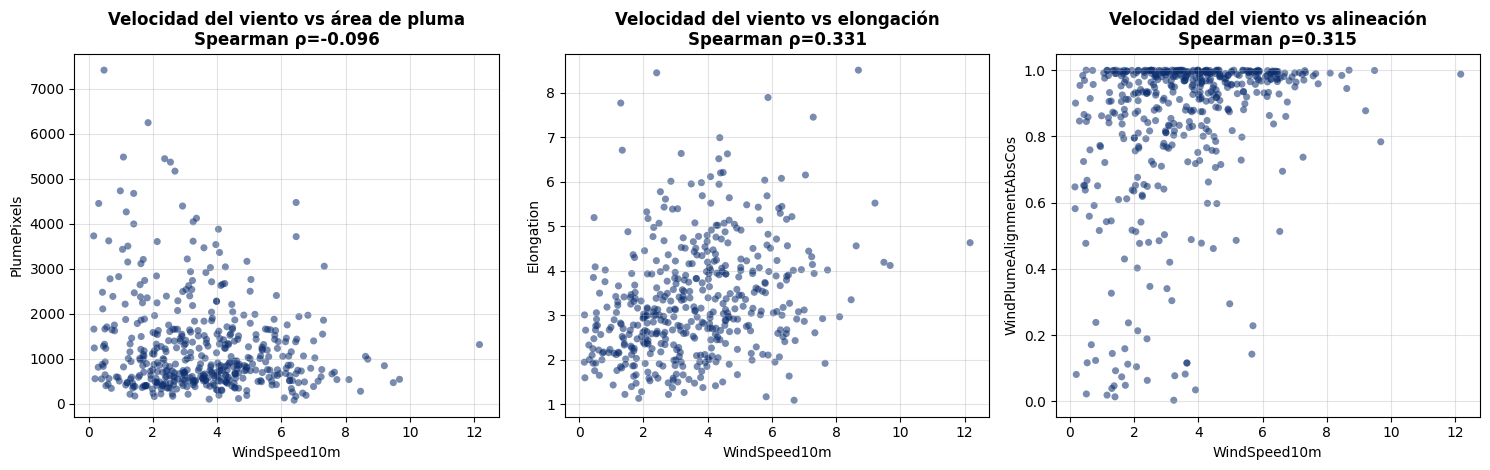

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/WindPlumeAlignment_Distribution.png


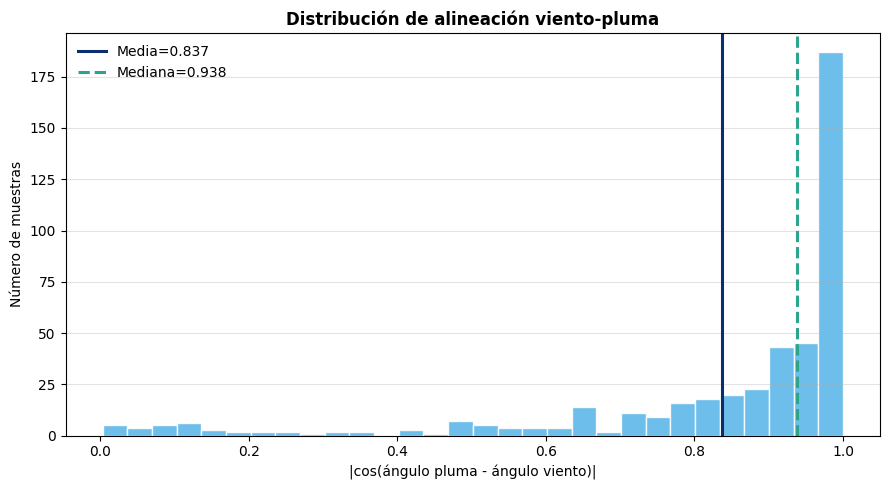

/tmp/ipykernel_2765029/1614463823.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/WindPlumeAlignment_ByWindSource.png


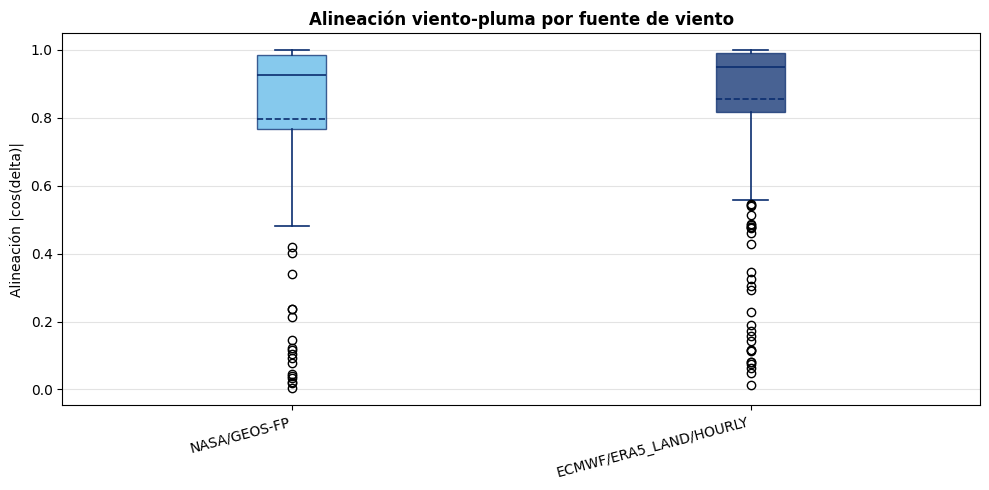

In [4]:
# =============================================================================
# Gráficas diagnósticas viento-pluma
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

FigDir = OutDir / "Figures"
FigDir.mkdir(parents=True, exist_ok=True)

def savefig(fig, filename):
    path = FigDir / filename
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    print("Saved:", path)

# 1. Wind speed vs PlumePixels / Elongation / Alignment
plot_df = WindPlumeEDA.copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

pairs = [
    ("WindSpeed10m", "PlumePixels", "Velocidad del viento vs área de pluma"),
    ("WindSpeed10m", "Elongation", "Velocidad del viento vs elongación"),
    ("WindSpeed10m", "WindPlumeAlignmentAbsCos", "Velocidad del viento vs alineación"),
]

for ax, (xcol, ycol, title) in zip(axes, pairs):
    df = plot_df[np.isfinite(plot_df[xcol]) & np.isfinite(plot_df[ycol])].copy()

    ax.scatter(
        df[xcol],
        df[ycol],
        s=26,
        alpha=0.55,
        color="#0B2E6F",
        edgecolor="none",
    )

    corr = df[[xcol, ycol]].corr(method="spearman").iloc[0, 1]

    ax.set_title(f"{title}\nSpearman ρ={corr:.3f}", fontweight="bold")
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.35)

plt.tight_layout()
savefig(fig, "WindSpeed_vs_PlumeGeometry.png")
plt.show()

# 2. Distribución de alineación
fig, ax = plt.subplots(figsize=(9, 5))

valid_alignment = plot_df["WindPlumeAlignmentAbsCos"].dropna()

ax.hist(
    valid_alignment,
    bins=30,
    color="#5DB7E8",
    edgecolor="white",
    alpha=0.9,
)

ax.axvline(valid_alignment.mean(), color="#0B2E6F", linewidth=2.2, label=f"Media={valid_alignment.mean():.3f}")
ax.axvline(valid_alignment.median(), color="#2CA58D", linewidth=2.2, linestyle="--", label=f"Mediana={valid_alignment.median():.3f}")

ax.set_title("Distribución de alineación viento-pluma", fontweight="bold")
ax.set_xlabel("|cos(ángulo pluma - ángulo viento)|")
ax.set_ylabel("Número de muestras")
ax.grid(True, axis="y", alpha=0.35)
ax.legend(frameon=False)

plt.tight_layout()
savefig(fig, "WindPlumeAlignment_Distribution.png")
plt.show()

# 3. Alineación por fuente de viento
fig, ax = plt.subplots(figsize=(10, 5))

sources = plot_df[WindSourceCol].dropna().unique()

data = [
    plot_df.loc[plot_df[WindSourceCol] == source, "WindPlumeAlignmentAbsCos"].dropna().values
    for source in sources
]

bp = ax.boxplot(
    data,
    labels=sources,
    patch_artist=True,
    showmeans=True,
    meanline=True,
)

colors = ["#5DB7E8", "#0B2E6F", "#2CA58D"]

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor("#0B2E6F")

for element in ["whiskers", "caps", "medians", "means"]:
    for item in bp[element]:
        item.set_color("#0B2E6F")
        item.set_linewidth(1.2)

ax.set_title("Alineación viento-pluma por fuente de viento", fontweight="bold")
ax.set_ylabel("Alineación |cos(delta)|")
ax.grid(True, axis="y", alpha=0.35)
plt.xticks(rotation=15, ha="right")

plt.tight_layout()
savefig(fig, "WindPlumeAlignment_ByWindSource.png")
plt.show()

In [5]:
WindPlumeEDA.groupby("Split")["WindPlumeAlignmentAbsCos"].describe()

,count,mean,std,min,25%,50%,75%,max
Split,,,,,,,,
Test,150.0,0.843615,0.235501,0.013378,0.820732,0.937951,0.989006,0.999962
Train,150.0,0.825954,0.252941,0.034190,0.807026,0.930680,0.990004,0.999999
Validation,150.0,0.840454,0.232827,0.003057,0.782522,0.949121,0.988467,0.999991


In [6]:
# =============================================================================
# Mini-verificación 1: robustez de alineación filtrando plumas pequeñas
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OutDir = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA" / "WindPlume"
FigDir = OutDir / "Figures"
OutDir.mkdir(parents=True, exist_ok=True)
FigDir.mkdir(parents=True, exist_ok=True)

def savefig(fig, filename):
    path = FigDir / filename
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    print("Saved:", path)

thresholds = [0, 25, 50, 100, 200, 300, 500, 1000]

robust_rows = []

for threshold in thresholds:
    df = WindPlumeEDA[
        (WindPlumeEDA["PlumePixels"] >= threshold)
        & np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
        & np.isfinite(WindPlumeEDA["WindSpeed10m"])
        & np.isfinite(WindPlumeEDA["Elongation"])
    ].copy()

    if len(df) == 0:
        continue

    robust_rows.append({
        "MinPlumePixels": threshold,
        "Samples": len(df),
        "AlignmentMean": df["WindPlumeAlignmentAbsCos"].mean(),
        "AlignmentMedian": df["WindPlumeAlignmentAbsCos"].median(),
        "AlignmentP25": df["WindPlumeAlignmentAbsCos"].quantile(0.25),
        "AlignmentP75": df["WindPlumeAlignmentAbsCos"].quantile(0.75),
        "AngleDiffMedianDeg": df["WindPlumeAngleDiffDeg_Axis"].median(),
        "Spearman_WindSpeed_Elongation": df[["WindSpeed10m", "Elongation"]].corr(method="spearman").iloc[0, 1],
        "Spearman_WindSpeed_PlumePixels": df[["WindSpeed10m", "PlumePixels"]].corr(method="spearman").iloc[0, 1],
        "Spearman_WindSpeed_Alignment": df[["WindSpeed10m", "WindPlumeAlignmentAbsCos"]].corr(method="spearman").iloc[0, 1],
    })

RobustAlignment = pd.DataFrame(robust_rows)

robust_path = OutDir / "WindPlumeAlignment_RobustnessByPlumeSize.csv"
RobustAlignment.to_csv(robust_path, index=False)

print("Saved:", robust_path)
display(RobustAlignment)

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/WindPlumeAlignment_RobustnessByPlumeSize.csv


,MinPlumePixels,Samples,AlignmentMean,AlignmentMedian,AlignmentP25,AlignmentP75,AngleDiffMedianDeg,Spearman_WindSpeed_Elongation,Spearman_WindSpeed_PlumePixels,Spearman_WindSpeed_Alignment
0,0,450,0.836674,0.937867,0.799647,0.989006,20.299939,0.331239,-0.095896,0.314764
1,25,450,0.836674,0.937867,0.799647,0.989006,20.299939,0.331239,-0.095896,0.314764
2,50,450,0.836674,0.937867,0.799647,0.989006,20.299939,0.331239,-0.095896,0.314764
3,100,448,0.836222,0.937867,0.798930,0.988928,20.299939,0.336271,-0.090526,0.312573
4,200,439,0.833520,0.935074,0.794969,0.988967,20.759863,0.347205,-0.079147,0.321111
5,300,428,0.833153,0.935178,0.794322,0.989524,20.743117,0.347027,-0.072946,0.316055
6,500,361,0.839004,0.940621,0.803214,0.989045,19.843958,0.376993,-0.169086,0.352364
7,1000,207,0.830939,0.935281,0.792782,0.989579,20.726370,0.340701,-0.237842,0.389041


Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/07_WindPlumeAlignment_RobustnessByPlumeSize.png


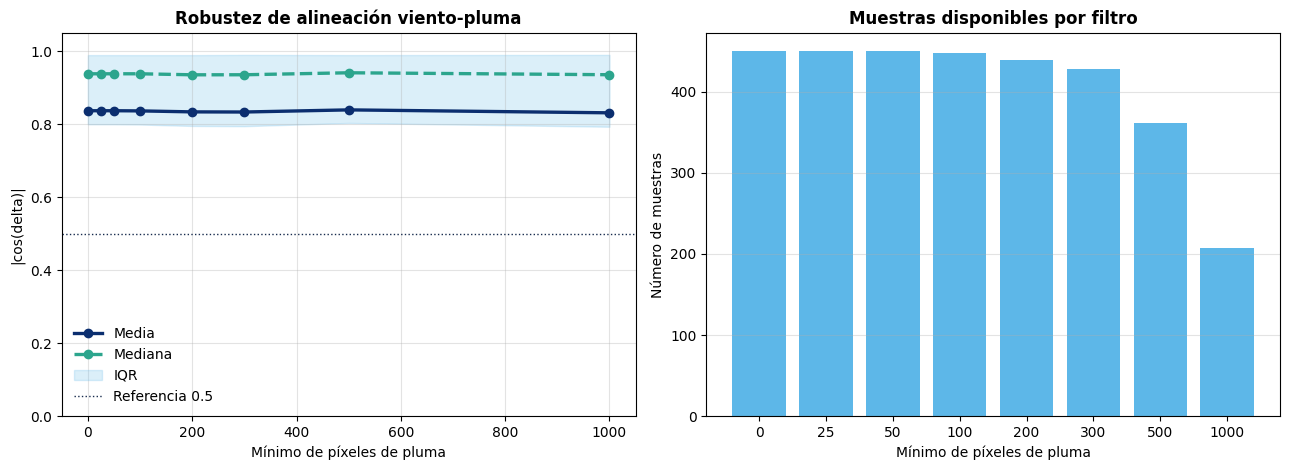

In [7]:
# =============================================================================
# Figura: robustez de alineación según tamaño mínimo de pluma
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Alineación
ax = axes[0]
ax.plot(
    RobustAlignment["MinPlumePixels"],
    RobustAlignment["AlignmentMean"],
    marker="o",
    linewidth=2.4,
    label="Media",
    color="#0B2E6F",
)
ax.plot(
    RobustAlignment["MinPlumePixels"],
    RobustAlignment["AlignmentMedian"],
    marker="o",
    linewidth=2.4,
    linestyle="--",
    label="Mediana",
    color="#2CA58D",
)

ax.fill_between(
    RobustAlignment["MinPlumePixels"],
    RobustAlignment["AlignmentP25"],
    RobustAlignment["AlignmentP75"],
    color="#5DB7E8",
    alpha=0.22,
    label="IQR",
)

ax.axhline(0.5, color="#172B4D", linewidth=1.0, linestyle=":", label="Referencia 0.5")
ax.set_title("Robustez de alineación viento-pluma", fontweight="bold")
ax.set_xlabel("Mínimo de píxeles de pluma")
ax.set_ylabel("|cos(delta)|")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.35)
ax.legend(frameon=False)

# Número de muestras
ax = axes[1]
ax.bar(
    RobustAlignment["MinPlumePixels"].astype(str),
    RobustAlignment["Samples"],
    color="#5DB7E8",
    edgecolor="none",
)
ax.set_title("Muestras disponibles por filtro", fontweight="bold")
ax.set_xlabel("Mínimo de píxeles de pluma")
ax.set_ylabel("Número de muestras")
ax.grid(True, axis="y", alpha=0.35)

plt.tight_layout()
savefig(fig, "07_WindPlumeAlignment_RobustnessByPlumeSize.png")
plt.show()

In [8]:
# =============================================================================
# Mini-verificación 2: alineación por split y fuente
# =============================================================================

valid = WindPlumeEDA[
    np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
].copy()

BySplitSource = (
    valid
    .groupby(["Split", WindSourceCol], as_index=False)
    .agg(
        Samples=("SampleId", "nunique"),
        AlignmentMean=("WindPlumeAlignmentAbsCos", "mean"),
        AlignmentMedian=("WindPlumeAlignmentAbsCos", "median"),
        AlignmentP25=("WindPlumeAlignmentAbsCos", lambda x: x.quantile(0.25)),
        AlignmentP75=("WindPlumeAlignmentAbsCos", lambda x: x.quantile(0.75)),
        WindSpeedMean=("WindSpeed10m", "mean"),
        ElongationMean=("Elongation", "mean"),
        PlumePixelsMedian=("PlumePixels", "median"),
    )
)

split_source_path = OutDir / "WindPlumeAlignment_BySplitAndSource.csv"
BySplitSource.to_csv(split_source_path, index=False)

print("Saved:", split_source_path)
display(BySplitSource)

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/WindPlumeAlignment_BySplitAndSource.csv


,Split,detection:wind_source,Samples,AlignmentMean,AlignmentMedian,AlignmentP25,AlignmentP75,WindSpeedMean,ElongationMean,PlumePixelsMedian
0,Test,ECMWF/ERA5_LAND/HOURLY,107,0.841176,0.935281,0.825090,0.988557,3.686556,3.357586,880.0
1,Test,NASA/GEOS-FP,43,0.849686,0.956531,0.818978,0.989390,3.512957,3.476464,855.0
2,Train,ECMWF/ERA5_LAND/HOURLY,93,0.856939,0.954583,0.856263,0.992844,3.579006,3.347994,904.0
3,Train,NASA/GEOS-FP,57,0.775399,0.874445,0.667311,0.979717,3.276478,3.068072,1020.0
4,Validation,ECMWF/ERA5_LAND/HOURLY,103,0.871326,0.955093,0.799349,0.990141,3.874799,3.492694,913.0
5,Validation,NASA/GEOS-FP,47,0.772799,0.917441,0.747091,0.982327,3.207451,2.893924,729.0


In [9]:
# =============================================================================
# Mini-verificación 3: casos visuales con vector de viento y eje de pluma
# =============================================================================

from Source.ReadTacoSample import ReadFullTacoSample
import numpy as np
import matplotlib.pyplot as plt

def normalize_for_display(arr, pmin=2, pmax=98):
    arr = np.asarray(arr, dtype=np.float32)
    finite = arr[np.isfinite(arr)]

    if finite.size == 0:
        return np.zeros_like(arr)

    lo, hi = np.percentile(finite, [pmin, pmax])

    if hi <= lo:
        return np.zeros_like(arr)

    return np.clip((arr - lo) / (hi - lo), 0, 1)


def plot_case_with_wind_and_plume_axis(ax, sample_id):
    sample = ReadFullTacoSample(
        Dataset=Dataset,
        SampleTable=SampleTable,
        SampleId=str(sample_id),
    )

    target = np.asarray(sample["Target"], dtype=np.float32)
    plume = np.asarray(sample["Plume"]) > 0

    row = WindPlumeEDA[WindPlumeEDA["SampleId"].astype(str) == str(sample_id)]

    if row.empty:
        raise ValueError(f"No encontré SampleId en WindPlumeEDA: {sample_id}")

    row = row.iloc[0]

    # Base visual: B12 si existe como canal 2, si no último canal disponible.
    base_idx = min(2, target.shape[0] - 1)
    base = normalize_for_display(target[base_idx])

    ax.imshow(base, cmap="gray", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(~plume, plume), cmap="autumn", alpha=0.55)

    cx = row["CentroidCol"]
    cy = row["CentroidRow"]

    if not np.isfinite(cx) or not np.isfinite(cy):
        ax.set_title(f"{sample_id}\nPluma insuficiente", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        return

    length = 38

    # Vector viento: x=east, y=north. En imagen, y positivo va hacia abajo.
    wx = row["WindDirCos10m"]
    wy = row["WindDirSin10m"]

    ax.arrow(
        cx,
        cy,
        length * wx,
        -length * wy,
        color="#7AD7E5",
        width=1.1,
        head_width=5,
        length_includes_head=True,
        label="Viento",
        zorder=5,
    )

    # Eje principal de pluma. Es axial, no direccional.
    theta = row["PlumeAngleMathRad"]
    px = np.cos(theta)
    py = np.sin(theta)

    ax.plot(
        [cx - length * px, cx + length * px],
        [cy + length * py, cy - length * py],
        color="#0B2E6F",
        linewidth=2.4,
        label="Eje pluma",
        zorder=6,
    )

    ax.scatter(
        [cx],
        [cy],
        s=34,
        color="white",
        edgecolor="#0B2E6F",
        linewidth=1.2,
        zorder=7,
    )

    ax.set_title(
        f"{row['Split']} | align={row['WindPlumeAlignmentAbsCos']:.2f}\n"
        f"speed={row['WindSpeed10m']:.2f} m/s | plume={int(row['PlumePixels'])}",
        fontsize=10,
        fontweight="bold",
    )

    ax.set_xticks([])
    ax.set_yticks([])


# Selección de casos
valid_cases = WindPlumeEDA[
    np.isfinite(WindPlumeEDA["WindPlumeAlignmentAbsCos"])
    & (WindPlumeEDA["PlumePixels"] >= 100)
].copy()

HighCases = valid_cases.sort_values("WindPlumeAlignmentAbsCos", ascending=False).head(3)
MidCases = valid_cases.iloc[
    (valid_cases["WindPlumeAlignmentAbsCos"] - 0.5).abs().sort_values().head(3).index
]
LowCases = valid_cases.sort_values("WindPlumeAlignmentAbsCos", ascending=True).head(3)

CaseSet = pd.concat(
    [
        HighCases.assign(CaseGroup="Alta alineación"),
        MidCases.assign(CaseGroup="Alineación media"),
        LowCases.assign(CaseGroup="Baja alineación"),
    ],
    ignore_index=True,
)

case_path = OutDir / "WindPlumeVectorCaseSet.csv"
CaseSet.to_csv(case_path, index=False)

print("Saved:", case_path)
display(CaseSet[["CaseGroup", "Split", "SampleId", "WindSpeed10m", "PlumePixels", "WindPlumeAlignmentAbsCos"]])

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/WindPlumeVectorCaseSet.csv


,CaseGroup,Split,SampleId,WindSpeed10m,PlumePixels,WindPlumeAlignmentAbsCos
0,Alta alineación,Train,d7985fe1-b429-4780-99c1-93cc707d4f3a,3.982758,1129,0.999999
1,Alta alineación,Validation,cf690495-a138-4bfc-a10c-60cb25f77b0c,2.549280,5370,0.999991
2,Alta alineación,Validation,7719d8f3-4559-4734-9468-853fa99c80be,4.562365,344,0.999975
3,Alineación media,Validation,125d6f11-60e2-4910-b9ac-6a63bb89e97e,3.235635,1365,0.003057
4,Alineación media,Train,8ad66e68-19bc-400e-99d9-8ce1994975ee,3.110891,503,0.419931
5,Alineación media,Train,318f229d-62aa-45b5-85fd-579da4e8bbbe,2.054886,1956,0.512099
6,Baja alineación,Validation,125d6f11-60e2-4910-b9ac-6a63bb89e97e,3.235635,1365,0.003057
7,Baja alineación,Test,032ebec4-17a8-4e1c-8f11-668230e37f2f,1.406072,3994,0.013378
8,Baja alineación,Validation,4b4796a8-8a34-43c5-b75e-e16b2379f7c2,1.159502,412,0.018501


Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/09_WindPlume_VectorCases_HighMidLow.png


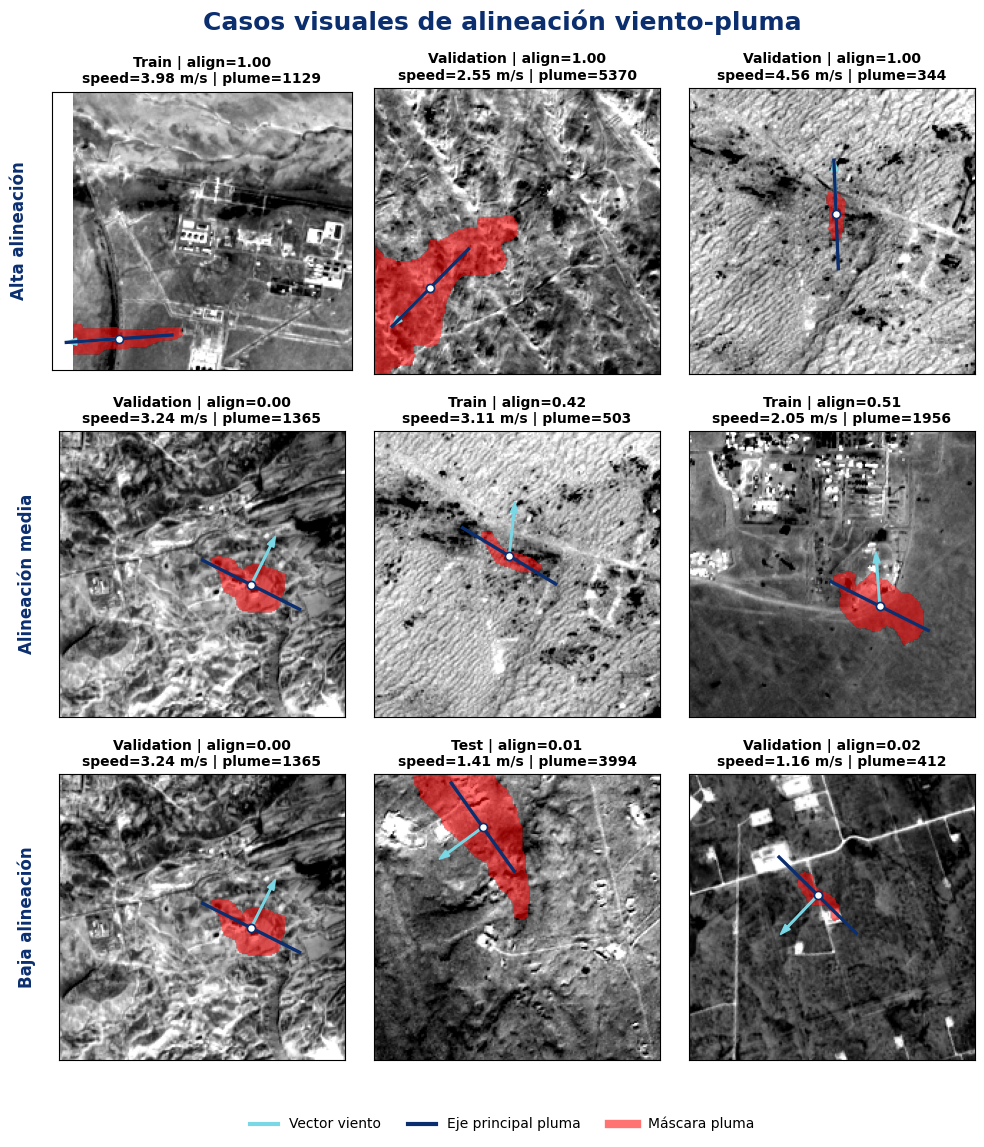

In [11]:
# =============================================================================
# Figura: casos visuales de alineación alta, media y baja
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

for ax, (_, row) in zip(axes, CaseSet.iterrows()):
    plot_case_with_wind_and_plume_axis(ax, row["SampleId"])

# Etiquetas de fila
row_labels = ["Alta alineación", "Alineación media", "Baja alineación"]
for i, label in enumerate(row_labels):
    axes[i * 3].text(
        -0.08,
        0.5,
        label,
        transform=axes[i * 3].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=12,
        fontweight="bold",
        color="#0B2E6F",
    )

# Leyenda manual
handles = [
    plt.Line2D([0], [0], color="#7AD7E5", linewidth=3, label="Vector viento"),
    plt.Line2D([0], [0], color="#0B2E6F", linewidth=3, label="Eje principal pluma"),
    plt.Line2D([0], [0], color="red", linewidth=6, alpha=0.55, label="Máscara pluma"),
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
)

fig.suptitle(
    "Casos visuales de alineación viento-pluma",
    fontsize=18,
    fontweight="bold",
    color="#0B2E6F",
    y=0.965,
)

fig.subplots_adjust(top=0.90, bottom=0.09, wspace=0.05, hspace=0.20)

savefig(fig, "09_WindPlume_VectorCases_HighMidLow.png")
plt.show()

In [12]:
# =============================================================================
# Tabla final de decisión para ConfigC
# =============================================================================

DecisionSummary = pd.DataFrame([
    {
        "Criterion": "WindSpeed vs Elongation",
        "Metric": "Spearman rho",
        "Value": WindPlumeEDA[
            np.isfinite(WindPlumeEDA["WindSpeed10m"])
            & np.isfinite(WindPlumeEDA["Elongation"])
        ][["WindSpeed10m", "Elongation"]].corr(method="spearman").iloc[0, 1],
        "Interpretation": "Relación positiva esperada: vientos más fuertes tienden a elongar la pluma.",
    },
    {
        "Criterion": "WindSpeed vs PlumePixels",
        "Metric": "Spearman rho",
        "Value": WindPlumeEDA[
            np.isfinite(WindPlumeEDA["WindSpeed10m"])
            & np.isfinite(WindPlumeEDA["PlumePixels"])
        ][["WindSpeed10m", "PlumePixels"]].corr(method="spearman").iloc[0, 1],
        "Interpretation": "Relación débil esperada: el área depende de emisión/observación más que solo viento.",
    },
    {
        "Criterion": "Wind-Plume Alignment",
        "Metric": "Mean |cos(delta)|",
        "Value": WindPlumeEDA["WindPlumeAlignmentAbsCos"].mean(),
        "Interpretation": "Valores altos indican paralelismo entre eje de pluma y vector de viento.",
    },
    {
        "Criterion": "Wind-Plume Alignment",
        "Metric": "Median |cos(delta)|",
        "Value": WindPlumeEDA["WindPlumeAlignmentAbsCos"].median(),
        "Interpretation": "Mediana alta refuerza que la alineación no depende solo de outliers.",
    },
])

decision_path = OutDir / "ConfigC_WindJustificationSummary.csv"
DecisionSummary.to_csv(decision_path, index=False)

print("Saved:", decision_path)
display(DecisionSummary)

Saved: /data/users/kabasmen/MethaneProjectTFM/Outputs/Experiments/Exp271431/EDA/WindPlume/ConfigC_WindJustificationSummary.csv


,Criterion,Metric,Value,Interpretation
0,WindSpeed vs Elongation,Spearman rho,0.331239,Relación positiva esperada: vientos más fuerte...
1,WindSpeed vs PlumePixels,Spearman rho,-0.095896,Relación débil esperada: el área depende de em...
2,Wind-Plume Alignment,Mean |cos(delta)|,0.836674,Valores altos indican paralelismo entre eje de...
3,Wind-Plume Alignment,Median |cos(delta)|,0.937867,Mediana alta refuerza que la alineación no dep...


Script Ajustado

In [14]:
# =============================================================================
# ConfigC Wind EDA — Notebook unificado
# Todas las figuras con estilo Montserrat / paleta azul
# Guardadas en: Outputs/Experiments/Exp271431/EDA/WindPlume/Figures/
# =============================================================================
 
# ── IMPORTS Y RUTAS ───────────────────────────────────────────────────────────
from pathlib import Path
import sys
import math
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
 
ProjectRoot = Path("/data/users/kabasmen/MethaneProjectTFM")
if str(ProjectRoot) not in sys.path:
    sys.path.insert(0, str(ProjectRoot))
 
RunTag    = "Exp271431"
TablesRoot = ProjectRoot / "Outputs" / "Experiments" / RunTag / "Tables"
OutDir    = ProjectRoot / "Outputs" / "Experiments" / RunTag / "EDA" / "WindPlume"
FigDir    = OutDir / "Figures"
OutDir.mkdir(parents=True, exist_ok=True)
FigDir.mkdir(parents=True, exist_ok=True)

In [15]:
# ── ESTILO GLOBAL ─────────────────────────────────────────────────────────────
BLUE_DARK   = "#0B2E6F"
BLUE_MID    = "#1A5FA8"
BLUE_LIGHT  = "#5DB7E8"
BLUE_PALE   = "#C9E6F7"
TEAL        = "#2CA58D"
WHITE       = "#FFFFFF"
 
FONT_FAMILY = "Montserrat"

In [16]:
# Verificar si Montserrat está disponible; si no, caer en DejaVu Sans
_available = [f.name for f in fm.fontManager.ttflist]
if FONT_FAMILY not in _available:
    FONT_FAMILY = "DejaVu Sans"
 
plt.rcParams.update({
    "font.family":          FONT_FAMILY,
    "axes.titlesize":       13,
    "axes.titleweight":     "bold",
    "axes.labelsize":       11,
    "axes.spines.top":      False,
    "axes.spines.right":    False,
    "axes.edgecolor":       "#CCCCCC",
    "axes.linewidth":       0.8,
    "xtick.labelsize":      9,
    "ytick.labelsize":      9,
    "legend.fontsize":      9,
    "figure.facecolor":     WHITE,
    "axes.facecolor":       WHITE,
    "grid.color":           "#E5E5E5",
    "grid.linewidth":       0.7,
    "savefig.dpi":          240,
    "savefig.bbox":         "tight",
    "savefig.facecolor":    WHITE,
})
 
SAVEKW = dict(dpi=240, bbox_inches="tight", facecolor=WHITE)
 
def savefig(fig, filename):
    path = FigDir / filename
    fig.savefig(path, **SAVEKW)
    print("Saved:", path)

In [18]:
# ── CARGAR DATOS ──────────────────────────────────────────────────────────────
from Source.TacoIndex import LoadTacoDataset, GetSampleTable
from Source.ReadTacoSample import ReadFullTacoSample
 
DatasetPath = Path("/data/databases/METHANE_DATASETS_TACOv2")
Dataset, _  = LoadTacoDataset(DatasetPath, "methaneset")
SampleTable = GetSampleTable(Dataset)
 
# Normalizar IDs y columnas de viento
IdCandidates = ["SampleId", "sample_id", "id", "Id", "ID"]
IdCol = next((c for c in IdCandidates if c in SampleTable.columns), None)
SampleTable = SampleTable.copy()
if IdCol is None:
    SampleTable["SampleId"] = SampleTable.index.astype(str)
else:
    SampleTable["SampleId"] = SampleTable[IdCol].astype(str)
 
WindUCol     = "meteo:wind_u"
WindVCol     = "meteo:wind_v"
WindSourceCol = "detection:wind_source"
 
eps = 1e-6
SampleTable["WindU"] = pd.to_numeric(SampleTable[WindUCol], errors="coerce")
SampleTable["WindV"] = pd.to_numeric(SampleTable[WindVCol], errors="coerce")
SampleTable["WindSpeed10m"]    = np.sqrt(SampleTable["WindU"]**2 + SampleTable["WindV"]**2)
SampleTable["WindDirRad_To"]   = np.arctan2(SampleTable["WindV"], SampleTable["WindU"])
SampleTable["WindDirDeg_To"]   = (np.degrees(SampleTable["WindDirRad_To"]) + 360) % 360
SampleTable["WindDirCos10m"]   = SampleTable["WindU"] / (SampleTable["WindSpeed10m"] + eps)
SampleTable["WindDirSin10m"]   = SampleTable["WindV"] / (SampleTable["WindSpeed10m"] + eps)
 
print("SampleTable:", SampleTable.shape)
print(SampleTable[["SampleId", WindSourceCol, "WindU", "WindV",
                    "WindSpeed10m", "WindDirDeg_To"]].head())
 

FileNotFoundError: No existe la ruta del dataset TACO: /data/databases/METHANE_DATASETS_TACOv2/methaneset